**Table of contents**<a id='toc0_'></a>    
- [Tutorial](#toc1_)    
  - [Information](#toc1_1_)    
    - [Time and Memory](#toc1_1_1_)    
    - [Naming convention](#toc1_1_2_)    
    - [Modules that are not shown](#toc1_1_3_)    
  - [Setup the fluorophore system](#toc1_2_)    
  - [Photophysical states](#toc1_3_)    
  - [Setup a transition](#toc1_4_)    
  - [Setup the transition set](#toc1_5_)    
  - [Simulations](#toc1_6_)    
    - [Detailed simulation](#toc1_6_1_)    
      - [Predict some statistics of the Markov chain](#toc1_6_1_1_)    
      - [Detailed simulation](#toc1_6_1_2_)    
      - [Analysis to extract statistics of the simulation](#toc1_6_1_3_)    
    - [Simulation of photons per frames only](#toc1_6_2_)    
    - [Simulation of pulsed excitation](#toc1_6_3_)    
    - [Simulation using GPU](#toc1_6_4_)    
    - [Simulation in parallel using ray](#toc1_6_5_)    
    - [Simulation Approximation](#toc1_6_6_)    
  - [Emissions](#toc1_7_)    
  - [FCS](#toc1_8_)    
  - [Blinking](#toc1_9_)    
  - [Multiple plot routines](#toc1_10_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# Overview
Continuous time markov chains (CTMC) are used to model the emission behavior of fluorophores. \
The number of fluorophores is limited (e.g., 4) due to exponentially scaling memory usage of the transition matrix. \
The fluorophores are in fixed positions. 
> [!NOTE]
> This resembles e.g., a protein dimer labeled with two different fluorophores. Even though the protein is likely mobile, the relative positions of the fluorophores are expected to be constant. Rotational movement or restrictions of such can be handled with the dipole orientation factor &kappa;².

The package offers: 
- very detailed simulation (information about all transitions and states)
- different simulation options depending on concerns
  - detailed: ✔️ information ❌ time and memory
  - frames: ✔️ low memory ❌ time, only emission data
  - approx: ✔️ information, time ❌ statistically incorrect
  - parallel: ✔️ via Ray ✔️ via GPU
- virtually all transitions possible
- unlimited amount of different energy transfers simultaneously

Parameters needed for accurate simulation:
- emission and absorption data of involved fluorophores**
- photophysical model (states, transitions, rates)
- positions of the fluorophores
- laser irradiance [W/m²], wavelength [m]
- frame integration time [s]
- bandpass range
- EMCCD gain
- photon collection rate objective
- quantum efficiency detector
- dark noise, readout noise

**The data should contain all integer wavelengths between 200 and 1000 nm. Absorption data should contain absolute extinction coefficients.
  
> [!IMPORTANT]
> Sometimes, a transition can 'partially' happen, meaning it depletes a certain initial state but doesn't end up in the intended final state. The same is true for energy transfers: if the acceptor is only roughly defined (e.g., with its name, but without electronic energy levels like S0, S1) it may be needed to define two transitions where one only depletes the donor. 

> [!NOTE]
> Markov chain topology and the photophysical context share some terms and one should be aware of the differences: due to computational advantage (explicit information), the photophysical transitions represent the Markovian states during simulation. The Markovian absorbing states correspond to the photophysically bleached states. 


# <a id='toc1_'></a>[Tutorial](#toc0_)

## <a id='toc1_1_'></a>[Information](#toc0_)

### <a id='toc1_1_1_'></a>[Time and Memory](#toc0_)
Time to simulate $n$ steps: $\mathcal{O}(n)$ \
Memory simulation: $\mathcal{O}(n)$ \
Time analysis: $\mathcal{O}(n)$ \
Memory analysis: $\mathcal{O}(n)$ \
Time number fluorophores $n$: $\mathcal{O}(n)$ \
Check with %%time and %memit

### <a id='toc1_1_2_'></a>[Naming convention](#toc0_)
|name|meaning|
|---|---|
|SingleState|photophysical state|
|PairedState|SingleStates of donor and acceptor combined|
|Transition|constant and variable attributes of photophysical transition|
|combined states|combinations of SingleStates depending on number of fluorophores|
|combined state transition|transitions between combined states|
|realizable|theoretically possible|

### <a id='toc1_1_3_'></a>[Modules that are not shown](#toc0_)
Modules that are not directly shown in tutorial: 
- formulas.py - most of it is used to automatically determine transition rates
- distributions.py - mainly to describe intensity distributions
- figure.py - used indirectly in most plotting routines
- fluo_data.py - used indirectly in fluorophores.py
- network.py - used indirectly in transitions.py and simulation.py
- fitting.py - used in other notebooks
- routines.py - used in other notebooks

In [ ]:
import numpy as np

import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_2_'></a>[Setup the fluorophore system](#toc0_)
fluorophores.py

Attributes of Fluorophore(identity=None, name='cy5_dna', position=array([0, 4]), constants=FluorophoreData(data_files='cy5_data', QUANTUM_YIELD=0.27, FLUORESCENCE_LIFETIME=1.7e-09, S1_QUENCH_RATE=0, ISC_ST_RATE=830000.0, ISC_TS_RATE=5000.0, RISC_RATE=0, STA_EFFICIENCY=0, PHOTOBLEACH_T1_RATE=10.0, PHOTOBLEACH_T2_RATE=0, DSTORM_PET_T_RATE_MOL=100000000.0, DSTORM_PET_S_RATE_MOL=1000000000.0, DSTORM_PET_SUCCESS_RATE=0.001, DSTORM_TH_EL_RATE_1=0.01, DSTORM_TH_EL_RATE_2=0, DSTORM_P_EL_CROSS_SECTION=6e-24, RAD_ESCAPE_EFFICIENCY=0.01, RAD_RELAX_RATE=1300.0, OFRET_EFFICIENCY=0.001, ISO_RATE=4000000.0, BISO_CROSS_SECTION=6e-18, BISO_THERMAL_RATE=5000.0, BISO_EFFICIENCY=0.04, H2O_ATTACK_S=0, H2O_ATTACK_T=0, BACK_REACTION=0)):
.................................................................
identity = None
_________________________________________________________________
name = 'cy5_dna'
_________________________________________________________________
position = array([0, 4])
___________________

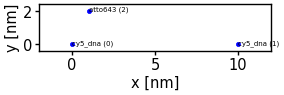

In [6]:
# Method 1: define the positions freely
fluorophore_1 = fl.Fluorophore(name="cy5_dna", position=[0, 4])
fluorophore_2 = fl.Fluorophore(name="cy5_dna", position=[4.5, 3])
fluorophores = [fluorophore_1, fluorophore_2]

# Method 2: collection of fluorophores in a certain shape
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=10, count=2, shape="square"
)
fluorophores.append(fl.Fluorophore(name="atto643", position=[1, 2]))

mi.print_class(fluorophore_1)

# FluorophoreSystem only takes the collection of fluorophores as parameter
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

mi.print_class(fluorophore_system)

fluorophore_system.plot(scale=0.5, quadratic=True);

## <a id='toc1_3_'></a>[Photophysical states](#toc0_)
transitions.py

This links the numbers (ids) to the actual photophysical state names. Later, in 
transition_set.single_states, only the 'relevant' states are mentioned - the ones that
actually occur in transition_set.plot(). \
Note: transitions that have a rate of 0 or are not usable by the fluorophore do not 
occur; however, transitions that may not be reachable still do.

In [7]:
# lists all photophysical states and their corresponding identifier
print("photophysical state and identifier:")
for single_state in tr.SingleState:
    print(single_state.name, single_state.value)

photophysical state and identifier:
S0 0
S1 1
S2 2
T1 3
T2 4
B 5
cis 6
OFF 7
OFF2 8
R 9


## <a id='toc1_4_'></a>[Setup a transition](#toc0_)
transitions.py

In [8]:
# each Transition involves some single or paired (energy transfer) photophysical states
s0 = tr.SingleState.S0
s0_s1 = tr.PairedState.S0_S1

print(
    f"{s0 = }\n{s0.value = }\n{s0_s1 = }\n{s0_s1.single_state_values = }\n"
    f"{s0_s1.acceptor = }\n{s0_s1.donor = }\n"
)

# each Transition is of a certain TransitionType
transition_type = tr.TransitionType.EXCITATION

mi.print_class(transition_type.value)

# initializing a transition
transition = tr.Transition(
    transition_type=transition_type, rate=1e6, fluorophore_ids=[1]
)

mi.print_class(transition)

s0 = <SingleState.S0: 0>
s0.value = 0
s0_s1 = <PairedState.S0_S1: [<SingleState.S0: 0>, <SingleState.S1: 1>]>
s0_s1.single_state_values = (0, 1)
s0_s1.acceptor = <SingleState.S1: 1>
s0_s1.donor = <SingleState.S0: 0>

Attributes of TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False):
.................................................................
abbreviation = 'EXC'
_________________________________________________________________
initial_state = <SingleState.S0: 0>
_________________________________________________________________
final_state = <SingleState.S1: 1>
_________________________________________________________________
photon = False
_________________________________________________________________


Attributes of Transition(identity=None, transition_type=<TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>

## <a id='toc1_5_'></a>[Setup the transition set](#toc0_)
transitions.py

'overwrite', 'exclude' or 'include' in energy_transfer_parameters will effect all types of fluorophores.


Attributes of <fluopy.transitions.TransitionSet object at 0x000001E8CBFD7E00>:
.................................................................
transitions = {'D: atto643, ..., dist: 2.236': [Transition(identity=32, transition_type=<Transit...1.10366), photon=False, fluorophore_ids=[(2, 0)]), Transition(identity=33, transition_type=<Transit...7527894), photon=False, fluorophore_ids=[(2, 0)]), Transition(identity=34, transition_type=<Transit...91.8604), photon=False, fluorophore_ids=[(2, 0)]), Transition(identity=35, transition_type=<Transit...06.3586), photon=False, fluorophore_ids=[(2, 0)]), Transition(identity=36, transition_type=<Transit....913862), photon=False, fluorophore_ids=[(2, 0)]), Transition(identity=37, transition_type=<Transit....691386), photon=False, fluorophore_ids=[(2, 0)]), ...], 'D: atto643, ...a, dist: 9.22': [Transition(identity=39, transition_type=<Transit...4183033), photon=False, fluorophore_ids=[(2, 1)]), Transition(identity=40, transition_type=<Transit...565

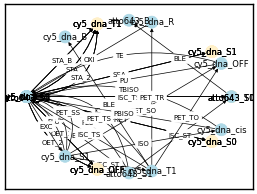

In [9]:
# Method 1: define the transitions freely
transition_1 = tr.Transition(
    tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0]
)
transition_2 = tr.Transition(
    tr.TransitionType.FLUORESCENT_EMISSION, rate=1e9, fluorophore_ids=[0]
)
transition_3 = tr.Transition(tr.TransitionType.FRET, rate=4e6, fluorophore_ids=[(0, 1)])
transitions = {
    "cy5_dna": [transition_1, transition_2],
    "D: cy5_dna, A: cy5_dna, dist: 10.0": [transition_3],
}

# Method 2: load a transition set, if available
transitions = fluorophore_system.load_transitions(
    summarize=False,
    irradiance=2.5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "betaME", "concentration": 143, "ph": 8},
    energy_transfer_parameters={
        "dipole_orientation_factor": 2 / 3,
        "refractive_index": 1.3,
        "overwrite": {
            "t1": [0.1, 0.9]
        },  # overwrites the rates of energy transfers with
        # s0 as acceptor (i.e., their total rate is now
        # 0.1 times as large) and the second values means
        # that 90% of the energy transfers will not end up
        # in the same acceptor state
        "exclude": ["cis"],  # excludes all energy transfers with cis as acceptor
        "include": {"t1": [(tr.TransitionType.S_T_ANNI_BLEACH, 0.5)]},
        # includes the specified energy transfer with an efficiency of the specified value
        # this is on top of overwrite meaning the specified energy transfers will always
        # have the specified efficiency opposed to the efficiencies in overwrite
    },
)

transition_set = tr.TransitionSet(transitions, fluorophore_system)
# the transition_set can be easily modified with the following methods
transition_set_no_bleaching = transition_set.remove_absorbing_states()
transition_set_no_ets = transition_set.remove_energy_transfers()
transition_set_filtered = transition_set.filter_by_identity(remove_list=[6])
transition_set_adj = transition_set.adjust_rates(
    change_dict={1: 1e3}, keep_zero_rates=False
)

# if everything is set, finalize TransitionSet
transition_set.finalize()

mi.print_class(transition_set)

transition_set.plot(graph_type="shell", colors=None, scale=0.5);

## <a id='toc1_6_'></a>[Simulations](#toc0_)

### <a id='toc1_6_1_'></a>[Detailed simulation](#toc0_)

#### <a id='toc1_6_1_1_'></a>[Predict some statistics of the Markov chain](#toc0_)
prediction.py

Rules for prediction:
- if energy transfers, pairs have separate color in plot but are normalized with other transitions of their donor
- absorbing states: the prediction works using the fundamental matrix. For Q, the transitions leading to an OVERALL absorbed state are dropped. This can be done since bleaching is usually by far the least occurring transition, meaning each fluorophore will reach its limiting distribution (as if it was no absorbing Markov Chain)
    - the frequencies and state occupations of absorbing transitions and states are set to 0, their lifetimes to inf (this is different to analysis, where - if absorbing transitions happened - only the lifetime and the state occupation is 0)

absorbing states have a lifetime of inf and a frequency / occupation of 0. Absorbing transitions have a frequency of 0.


Attributes of <fluopy.prediction.Prediction object at 0x0000023BD98A3B60>:
.................................................................
energy_transfer = False
_________________________________________________________________
absorbing_chain = True
_________________________________________________________________
transition_set = <fluopy.transitions.TransitionSet object at 0x0000023BDD665BF0>
_________________________________________________________________
frequency_transitions = array([4.97965155e-01, 1.33455110e-01, 6.9742652... 1.49773841e-03, 1.98202699e-01, 0.00000000e+00])
_________________________________________________________________
frequency_states = {'atto643': array([0.49925112, 0.49925113, 0.00149775, 0.        ]), 'cy5_dna': array([4.97965140e-01, 4.97965155e-01, 6.9742652... 4.36541316e-06, 6.82126839e-06, 0.00000000e+00])}
_________________________________________________________________
transition_time_distributions = array([<scipy.stats._distn_infrastructure.r

array([[<Axes: title={'center': '$\\tau$ of cy5_dna\n            EXC'}, xlabel='time to transition [s]', ylabel='PD'>]],
      dtype=object)

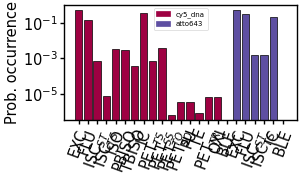

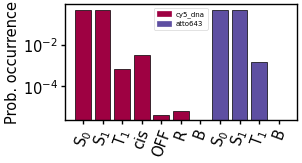

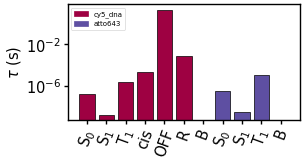

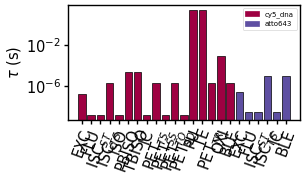

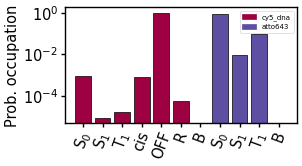

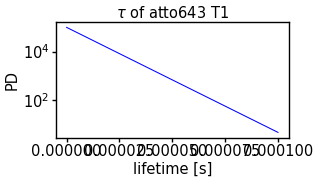

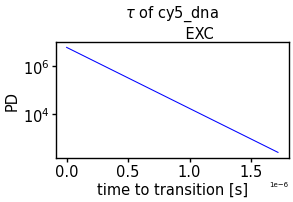

In [54]:
fluorophore_system = fl.FluorophoreSystem(
    fluorophores=[
        fl.Fluorophore(name="cy5_dna", position=[0, 0]),
        fl.Fluorophore(name="atto643", position=[0, 2]),
    ]
)
transitions = fluorophore_system.load_transitions(
    summarize=False,
    irradiance=2,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.remove_energy_transfers()
transition_set.finalize()

prediction = pr.Prediction(transition_set)
mi.print_class(prediction)

prediction.plot_frequency_transitions(scale=0.5)
prediction.plot_frequency_states(scale=0.5)
prediction.plot_mean_lifetimes(scale=0.5)
prediction.plot_mean_transition_times(scale=0.5)
prediction.plot_state_occupations(scale=0.5)
prediction.plot_lifetime_distributions(
    fluorophore="atto643", state_identity=3, scale=0.5
)
prediction.plot_transition_time_distributions(
    fluorophore="cy5_dna", transition_id=0, scale=0.5
)

#### <a id='toc1_6_1_2_'></a>[Detailed simulation](#toc0_)
simulation.py

In [51]:
rng = np.random.default_rng(42)
simulation = si.Simulation(transition_set)

# basic simulation run for a given number of steps (size)
# simulation.run(start_at=None, size=1e6, end_time=None, seed=rng, use_memmap=None)

# simulate until it reaches given end_time
simulation.run(start_at=None, size=1e6, end_time=1e-2, seed=rng, use_memmap=None)

# if a lot of steps have to be carried out, the arrays may become too large for RAM
# in that case, use memory maps store on drive
# simulation.run(start_at=None, size=1e6, end_time=None, seed=rng,
#                use_memmap=r'path')

mi.print_class(simulation)

Floating point precision error warning:
 The smallest safe increment is 1.73e-18.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1]
 gives a probability of 1.03e-09 for a smaller increment to be drawn.


Attributes of <fluopy.simulation.Simulation object at 0x0000023BD99A0410>:
.................................................................
transition_set = <fluopy.transitions.TransitionSet object at 0x0000023BDB024D70>
_________________________________________________________________
time_series = array([0.00000000e+00, 4.40600740e-08, 4.4317327... 9.99985633e-03, 1.00000000e-02], shape=(57940,))
_________________________________________________________________
transition_series = array([0, 7, 0, ..., 7, 0, 7], shape=(57938,), dtype=uint32)
_________________________________________________________________
state_series = array([[0, 1, 0, ..., 0, 1, 0]], shape=(1, 57939), dtype=int8)
_________________________________________________________________
memmap_path = None
_________________________________________________________________




#### <a id='toc1_6_1_3_'></a>[Analysis to extract statistics of the simulation](#toc0_)
analysis.py \
\
The analysis follows these rules:
- time to transitions of energy transfers are collected only from the donor's point of view
- time to transition of e.g., fluorescence, does not differentiate whether energy transfer was also an option or not
- one energy transfer transition occurrence resembles the transition of the donor and the acceptor
- state lifetimes and occurrences do not differentiate whether energy transfer was involved or not \
\
Note: energy transfer has an impact on true fluorescence lifetime only if the acceptors are truly available. If the potential acceptor is in a non-accepting state, the energy transfer is not available. If multiple fluorophores are potential acceptors, all of their respective rates are taken into account. Depending on the photophysical system, energy transfers may only have a marginal impact on the mean fluorescence lifetime.

Attributes of <fluopy.analysis.Analysis object at 0x0000023BEFC407D0>:
.................................................................
simulation = <fluopy.simulation.Simulation object at 0x0000023BD99A0410>
_________________________________________________________________
frequency_transitions = array([4.97859781e-01, 1.32175774e-01, 7.2491283...0000e+00, 0.00000000e+00,
       0.00000000e+00])
_________________________________________________________________
frequency_states = {'cy5_dna': array([0.49786845, 0.49785119, 0.0007249 , 0.00355546, 0.        ,
       0.        , 0.        ])}
_________________________________________________________________
transition_time_distributions = [array([4.40600740e-08, 4.06240937e-07, 3.5332591... 7.33218552e-08, 3.82729175e-08], shape=(28845,)), array([1.37229031e-09, 1.28584863e-09, 1.2756304..., 5.55581852e-09, 1.90334297e-09], shape=(7658,)), array([1.07436305e-09, 2.71017157e-09, 6.1632765...6188e-10,
       7.04058664e-10, 1.54056668e-10]

array([[<Axes: title={'center': '$\\tau$ of cy5_dna\n            EXC'}, xlabel='time to transition [s]', ylabel='PD'>]],
      dtype=object)

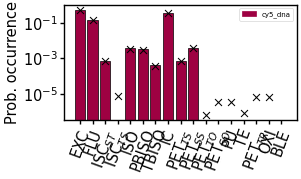

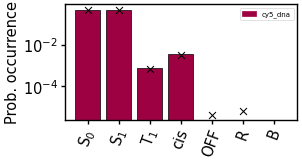

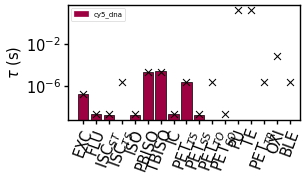

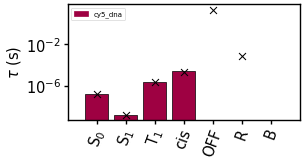

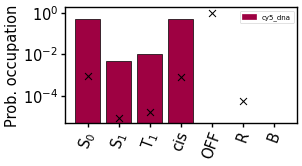

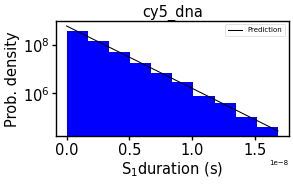

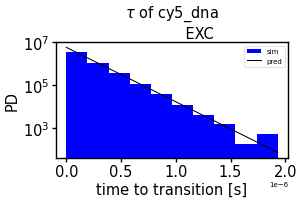

In [52]:
analysis = an.Analysis(simulation=simulation)

mi.print_class(analysis)

analysis.get_fluorescence_lifetimes(fluorophore="cy5_dna")
analysis.get_emitting_transition_lifetimes(fluorophore="cy5_dna")

analysis.plot_frequency_transitions(scale=0.5, prediction=prediction)
analysis.plot_frequency_states(scale=0.5, prediction=prediction)
analysis.plot_mean_transition_times(scale=0.5, prediction=prediction)
analysis.plot_mean_lifetimes(scale=0.5, prediction=prediction)
analysis.plot_state_occupations(scale=0.5, prediction=prediction)
analysis.plot_lifetime_distributions(
    scale=0.5, prediction=prediction, fluorophore="cy5_dna", state_identity=1
)
analysis.plot_transition_time_distributions(
    scale=0.5, prediction=prediction, fluorophore="cy5_dna", transition_id=0
)

### <a id='toc1_6_2_'></a>[Simulation of photons per frames only](#toc0_)
simulation.py and emissions.py \
\
Only yields experimentally observable information \
Much less memory consuming \
Subsequent statistical analysis not available \
Subsequent FCS and blinking available

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

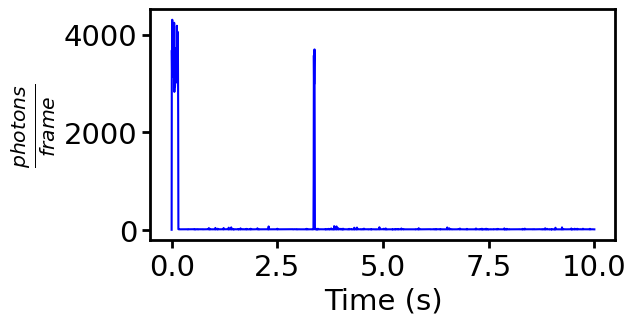

In [11]:
rng = np.random.default_rng(1)
fluorophore_system = fl.FluorophoreSystem(
    fluorophores=[
        fl.Fluorophore(name="cy5_dna", position=[0, 0]),
    ]
)
transitions = fluorophore_system.load_transitions(
    summarize=False,
    irradiance=2,
    wavelength=640,
    energy_transfer=True,
    dstorm=True,
    bleaching=True,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.remove_energy_transfers()
transition_set.finalize()
emis = em.Emissions(frame_time="5ms", seed=rng, bandpass=(600, 800))
emis.simulate(transition_set=transition_set, store_time_points=True, frames=2000)
# just like extracted emissions (see below), the follwoing routines can be applied
emis.add_photon_collection_objective(p=0.1, seed=rng)  # 1.
emis.add_quantum_efficiency(p=0.9, seed=rng)  # 3.1.
emis.add_poisson_noise(rate=0.05, seed=rng)  # 3.2. (dark noise), note the frame time
emis.add_emccd_gain(emccd_gain=10, seed=rng)  # 4.
emis.add_gaussian_noise(mean=10, std=1, seed=rng)  # 5. (readout noise)

emis.plot_time_series()

### <a id='toc1_6_3_'></a>[Simulation of pulsed excitation](#toc0_)
simulation_tcspc.py and emissions.py

The returned lifetimes are the time differences of photon emission to the last laser pulse. I.e., if the time between laser pulses is very short, it may shorten the observed lifetimes. It also does not discriminate between different fluorophores (i.e., if one fluorophore gets excited, it transfers the energy to another fluorophore, and this fluorophore emits a photon). However, if the fluorophores are different, only one of them may be directly excitable by the laser pulse (due to the wavelength) and, depending on the provided bandpass, only the fluorescence of the other may be detectable.\
\
If details is True, a simulation object will be returned with transition_series, state_series and time_series. Since the TCSPC simulation assumes a laser pulse to be instantaneous, a laser pulse that excited multiple fluorophores will lead to duplicates in the time series. This is handled by introducing minimal amount of spaces between these duplicates. The excitations are added in the correct order (fluorophore-specific) such that these series exaclty represent the transition chain, even with multiple different distances between energy transfer partners. Note that when monitoring the fluorescence lifetime via the simulation object it will be the true one (as opposed to the generally returned lifetimes, which are the observed ones).

*homo-FRET*\
The extra homo-FRET notebook is still better suited to simulate an idealized homo-FRET scenario, because there the between-pulse-time will always be sufficiently large.

'overwrite', 'exclude' or 'include' in energy_transfer_parameters will effect all types of fluorophores.
the last frame (of index 0.05) has 1.00e+00 times the pulses of other frames.


array([[<Axes: xlabel='Lifetime (s)', ylabel='PD'>]], dtype=object)

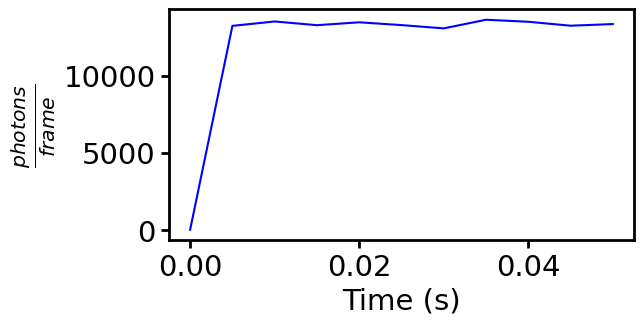

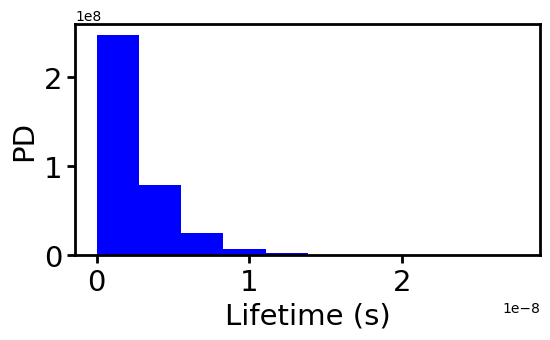

In [88]:
# cell takes 2 minutes to run
rng = np.random.default_rng(1)
fluorophore_system = fl.FluorophoreSystem(
    fluorophores=[
        fl.Fluorophore(name="cy5_dna", position=[0, 0]),
        fl.Fluorophore(name="atto643", position=[0, 8]),
    ]
)
transitions = fluorophore_system.load_transitions(
    summarize=False,
    irradiance=2,
    wavelength=640,
    energy_transfer=True,
    dstorm=True,
    bleaching=False,
    energy_transfer_parameters={"exclude": ["t1"]},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)

emis = em.Emissions(frame_time="5ms", seed=rng, bandpass=(600, 800))
lifetimes_DA, lifetimes_D, lifetimes_all, s = emis.tcspc(
    transition_set=transition_set,
    number_pulses=5e5,
    pulse_duration=1e-11,
    time_between_pulses=1e-7,
    excitation_rates={"cy5_dna": 0, "atto643": 1e11},
    size=1e5,
    store_time_points=True,
    # details = True
)
emis.plot_time_series()
fi.universal_figure(
    type_="hist", data=lifetimes_all, ylabel="PD", density=True, xlabel="Lifetime (s)"
)

### <a id='toc1_6_4_'></a>[Simulation using GPU](#toc0_)
simulation_GPU.py

In [ ]:
# import src.simulation_GPU as sigpu
# import cupy as cp

# # the device ids can differ from the ones displayed in task manager
# sigpu.list_devices()

# sorted_indic, cumsum = sigpu.prep_direct_method_time(transition_matrix=transition_set_2.transition_matrix)

# sorted_indic = cp.asarray(sorted_indic)
# cumsum = cp.asarray(cumsum)
# row_sums = cp.asarray(transition_set_2.row_sums)
# time_series, transition_series = sigpu.direct_method_time(sorted_indic, cumsum, row_sums, size=1000, end_time=1e-3)

pytorch device count: 1
pytorch device: 0
cupy device count: 1
cupy device: 0


### <a id='toc1_6_5_'></a>[Simulation in parallel using ray](#toc0_)
Not a multi-node-cluster, uses only the cores of the current device \
Multi-node-cluster on windows yet remains unsupported by ray

In [ ]:
# import ray

# ray.shutdown()  # needed to reinitialize ray if executed multiple times
# ray.init(runtime_env={"working_dir": path})

# @ray.remote
# def process_parallel(simulation, seed, **simulation_param):
#     simulation.run(
#         seed=seed, **simulation_param
#     )  # @ray.remote can also be used as decorator of class, see ray actors
#     time_series = simulation.time_series
#     transition_series = simulation.transition_series
#     state_series = simulation.state_series

#     return time_series, transition_series, state_series


# simulation = si.Simulation(transition_set)

# n_processes = 4
# seedseq = np.random.SeedSequence(12345)
# seeds = seedseq.spawn(n_processes)
# # create a 'promise' called futures, which needs to be fetched
# futures = [process_parallel.remote(simulation, seed, size=1e3) for seed in seeds]
# # fetch
# data = ray.get(futures)

WARNING for line:     from .autonotebook import tqdm as notebook_tqdm
 IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html 
2024-03-21 12:00:21,945	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-03-21 12:00:26,060	INFO worker.py:1715 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2024-03-21 12:00:48,498	INFO packaging.py:530 -- Creating a file package for local directory 'c:\Users\ebert\OneDrive - Universität Würzburg\GitHub\Photoswitching'.
2024-03-21 12:00:48,979	WARNING packaging.py:405 -- File c:\Users\ebert\OneDrive - Universität Würzburg\GitHub\Photoswitching\.git\objects\5d\9c4b6a9b2d54621d9048629e58f4d0210ab40c is very large (12.15MiB). Consider adding this file to the 'excludes' list to skip uploading it: `ray.init(..., runtime_env={'excludes': ['c:\Users\ebert\OneDrive - Univers

### <a id='toc1_6_6_'></a>[Simulation Approximation](#toc0_)
simulation.py

In [10]:
# cell takes 1 minute to run
rng = np.random.default_rng(3)
fluorophore_system = fl.FluorophoreSystem(
    fluorophores=[fl.Fluorophore(name="cy5_dna", position=[0, 0])]
)
transitions = fluorophore_system.load_transitions(
    irradiance=2, wavelength=640, bleaching=True, energy_transfer=True, dstorm=True
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.remove_energy_transfers()
transition_set.finalize()

prediction = pr.Prediction(transition_set)

approximation = si.Simulation(transition_set=transition_set)
approximation.approximate(prediction=prediction, size=1e8, seed=rng)

absorbing states have a lifetime of inf and a frequency / occupation of 0. Absorbing transitions have a frequency of 0.
approximation ignors absorbing states, they will not occur.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


## <a id='toc1_7_'></a>[Emissions](#toc0_)
emissions.py

Attributes of <fluopy.emissions.Emissions object at 0x000001E8CBFD74D0>:
.................................................................
parameters = {'bandpass': (660, 700), 'frame_time': '5ms', 'seed': Generator(PCG64) at 0x1E8CD1D6340}
_________________________________________________________________
event_time_points = array([2.02814481e-06, 2.09330625e-06, 2.6615931....45970421e+03, 9.45970421e+03], shape=(6982380,))
_________________________________________________________________
event_time_series[:6] = 0.000       0
0.005    6962
0.010     854
0.015       0
0.020       0
0.025       0
dtype: int32
_________________________________________________________________




array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

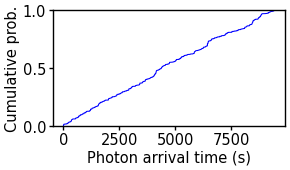

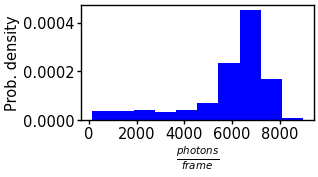

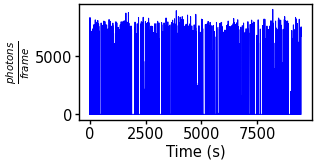

In [11]:
rng = np.random.default_rng(10)
# for multicolor dSTORM, instantiate two Emissions objects with different bandpasses
emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(660, 700))
emissions.extract(simulation=approximation)  # 2.
# at this point, the bandpass filter was applied
# yet, the effect of photon collection by the objective is missing
# the order is not relevant for two consecutive binomial distributions
# it is more convenient to apply the bandpass first because it needs the
# information about the emitting fluorophore whereas all the other effects are
# roughly wavelength independent
p_photon_collection = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emissions.add_photon_collection_objective(p=p_photon_collection, seed=rng)  # 1.
emissions.add_quantum_efficiency(p=0.9, seed=rng)  # 4.1.
emissions.add_transmittance(
    p=0.99, seed=rng
)  # 3 (depending on number of components of optical
# path, may be applied multiple times)
emissions.add_poisson_noise(
    rate=0.05, seed=rng
)  # 4.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10, seed=rng)  # 5. (+ multiplicative noise)
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 6. (readout noise)
# CIC (spurious noise) neglected since low probability to happen in the pixels of
# interest
emissions.apply_threshold(threshold=100)  # 7 (thresholding)
mi.print_class(emissions)

emissions.plot_cumulative_events(scale=0.5)
emissions.plot_histogram(scale=0.5)
emissions.plot_time_series(scale=0.5)

# to save the time_series and time_points
# emissions.save(path='', name_extension='test')

# to load time_series and time_points
# emissions.load(path='', name_extension='test')

## <a id='toc1_8_'></a>[FCS](#toc0_)

fcs.py

Attributes of <fluopy.fcs.FCS object at 0x000001E8DE622210>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x000001E8CBFD74D0>
_________________________________________________________________
autocorrelation = array([4.87078667e+02, 4.28317241e+02, 3.7614045... 9.88744569e-01, 1.00909653e+00, 1.00648238e+00])
_________________________________________________________________
tau = array([5.00000e-03, 1.00000e-02, 1.50000e-02, 2....6608e+03, 2.62144e+03, 3.93216e+03, 5.24288e+03])
_________________________________________________________________




array([[<Axes: xlabel='$\\tau$ (s)', ylabel='$g^{(2)}(\\tau)$'>]],
      dtype=object)

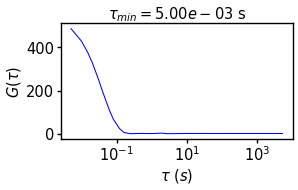

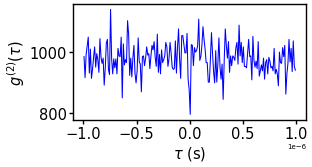

In [15]:
rng = np.random.default_rng(1)
fcs = fcs_p.FCS(emissions)

# autocorrelation via exact time points
fcs.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=4, normalize=True
)

# autocorrelation via lag times
fcs.autocorrelate_time_series(log=True, m=4, normalize=True)

mi.print_class(fcs)

fcs.plot(normalize_to=None, unit="s", scale=0.5)

# some fcs fits are available:
# fcs_predict = fcs_p.fit_dark(tau, dark_lifetime, dark_occupation)
# fcs_predict = fcs_p.fit_antibunching(tau, excitation_rate, s1_lifetime)
# fcs_predict = fcs_p.fit_triplet_cis(tau, k_isc, k_T, k_01, k_10, k_iso, k_biso_eff)

# sensible to tau_max and bin_width, see coincidence notebook
hist, bin_centers = fcs_p.coincidence(
    emissions.event_time_points[: int(2e5)], tau_max=1e-6, bin_width=1e-8, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    scale=0.5,
)

## <a id='toc1_9_'></a>[Blinking](#toc0_)
blinking.py \
\
An ON-period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). An OFF-period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).
Each ON-period is followed by an OFF-period and vice versa.

Attributes of <fluopy.blinking.Blinking object at 0x0000023BE66E6350>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x0000023BDD35F4D0>
_________________________________________________________________
on_periods = array([ 2, 18, 23,  4,  2,  3,  1,  3, 11,  4, 1...,  9,  4,  6,  9,  2,  2,
        2, 10, 16,  5])
_________________________________________________________________
off_periods = array([ 1423,   375,  2906,  7248,   118,  2200,... 4207,
        3985,  1917,  8097,   349,  8097])
_________________________________________________________________
on_periods_frames = array([      1,    1426,    1819,    4748,   120...    1869456, 1873443, 1875362, 1883469, 1883834])
_________________________________________________________________
off_periods_frames = array([      3,    1444,    1842,    4752,   120...    1869458, 1873445, 1875372, 1883485, 1883839])
_________________________________________________________

array([[<Axes: title={'center': 'analytical OFF'}, xlabel='time [s]'>]],
      dtype=object)

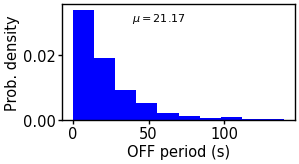

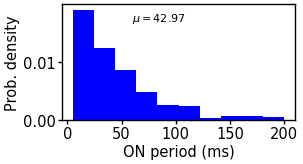

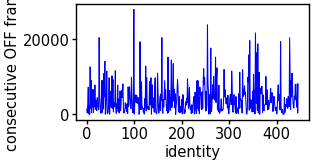

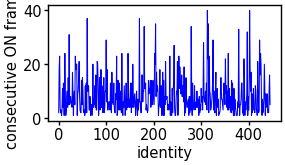

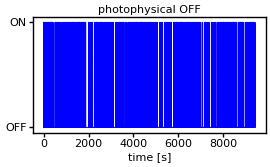

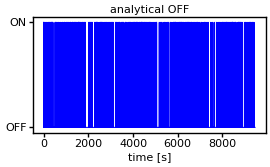

In [42]:
blinks = bl.Blinking(emissions)

mi.print_class(blinks)

# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="s", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)

# to get information of the photophysical (not analytical) OFF of each fluorophore, use
on_off_times_photophys, on_off_values_photophys = bl.get_off_statistics(
    simulation=approximation, index=0
)
# (version before 21.03.24: event_indices as parameter to take detected events into
# account)

# to get the analytical OFF statistics as the same view, use
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

# plot the photophysical OFF statistics
bl.plot_off_statistics(
    on_off_times_photophys,
    on_off_values_photophys,
    scale=0.5,
    title="photophysical OFF",
)
# plot the analytical OFF statistics (no differentiation between fluorophores)
bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=0.5, title="analytical OFF"
)

## <a id='toc1_10_'></a>[Multiple plot routines](#toc0_)
miscellaneous.py

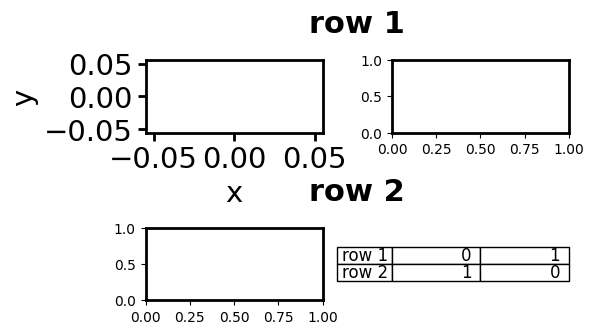

In [43]:
axes = fi.universal_figure(nrows=2, ncols=2)

# get the figure object
figure = mi.get_figure(axes)

# allign the individual plots
figure.tight_layout()

# delete a subplot
mi.delete_subplots(axes, keep_number=3, del_positions=None)

# add row subtitles
mi.create_row_subtitles(axes, nrows=2, ncols=2, titles=["row 1", "row 2"])

# add a table
mi.add_table(axes, np.array([[0, 1], [1, 0]]), labels=["row 1", "row 2"], grid=224)